In [1]:
import matplotlib.pyplot as plt
%matplotlib inline
import matplotlib_inline
matplotlib_inline.backend_inline.set_matplotlib_formats('svg', 'pdf')
import seaborn as sns

import importlib.util
import subprocess
import sys

if importlib.util.find_spec("equinox") is None:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "equinox"])

In [2]:
# BOOK_FIGURE_STYLE_CELL
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np

try:
    import seaborn as sns
except ImportError:
    sns = None

try:
    import matplotlib_inline

    matplotlib_inline.backend_inline.set_matplotlib_formats("svg", "pdf")
except Exception:
    matplotlib_inline = None

FIGURE_SIZES = {
    "full_landscape": (4.50, 3.10),
    "full_standard": (7.35, 4.90),
    "full_tall": (7.35, 5.50),
    "half_standard": (3.55, 2.55),
    "half_tall": (3.55, 3.05),
    "inset": (2.30, 1.75),
}

BOOK_COLORS = {
    "blue": "#4C78A8",
    "orange": "#F58518",
    "green": "#54A24B",
    "red": "#E45756",
    "gray": "#7F7F7F",
}

BOOK_TARGET = "web"


def setup_book_style(target="web"):
    global BOOK_TARGET
    BOOK_TARGET = target
    mpl.rcParams.update(
        {
            "figure.figsize": FIGURE_SIZES["half_standard"],
            "figure.dpi": 120,
            "savefig.dpi": 300,
            "savefig.bbox": "tight",
            "savefig.pad_inches": 0.02,
            "pdf.fonttype": 42,
            "ps.fonttype": 42,
            "font.family": "sans-serif",
            "font.sans-serif": ["DejaVu Sans", "Arial", "Liberation Sans"],
            "axes.labelsize": 9,
            "axes.titlesize": 9,
            "axes.linewidth": 0.8,
            "axes.grid": False,
            "axes.spines.top": False,
            "axes.spines.right": False,
            "xtick.labelsize": 8,
            "ytick.labelsize": 8,
            "xtick.major.width": 0.8,
            "ytick.major.width": 0.8,
            "legend.fontsize": 8,
            "legend.frameon": False,
            "lines.linewidth": 1.5,
            "lines.markersize": 4,
            "patch.linewidth": 0.8,
            "image.cmap": "Greys",
        }
    )
    if target == "latex":
        try:
            mpl.rcParams["text.usetex"] = False
        except Exception:
            mpl.rcParams["text.usetex"] = False


def new_figure(
    size="half_standard",
    nrows=1,
    ncols=1,
    sharex=False,
    sharey=False,
    constrained=True,
    squeeze=True,
    **kwargs,
):
    fig, ax = plt.subplots(
        nrows=nrows,
        ncols=ncols,
        sharex=sharex,
        sharey=sharey,
        constrained_layout=constrained,
        figsize=FIGURE_SIZES[size],
        squeeze=squeeze,
        **kwargs,
    )
    return fig, ax


def label_panels(axes=None, labels=None, x=0.02, y=0.98, **kwargs):
    if axes is None:
        axes = plt.gcf().axes
    axes = np.atleast_1d(axes).ravel()
    if labels is None:
        labels = [f"({chr(97 + i)})" for i in range(len(axes))]
    default = dict(
        fontsize=9,
        fontweight="bold",
        va="top",
        ha="left",
        transform=None,
        bbox=dict(facecolor="white", edgecolor="none", pad=0.8, alpha=0.9),
    )
    default.update(kwargs)
    for ax, label in zip(axes, labels):
        call_kwargs = dict(default)
        if call_kwargs["transform"] is None:
            call_kwargs["transform"] = ax.transAxes
        ax.text(x, y, label, **call_kwargs)


def finalize_axes(axes=None, keep_box=False, grid=False):
    if axes is None:
        axes = plt.gcf().axes
    axes = np.atleast_1d(axes).ravel()
    for ax in axes:
        if grid:
            ax.grid(axis="y", color="0.88", linewidth=0.6)
        else:
            ax.grid(False)
        for spine in ax.spines.values():
            spine.set_linewidth(0.8)
        if keep_box:
            ax.spines["top"].set_visible(True)
            ax.spines["right"].set_visible(True)
        else:
            ax.spines["top"].set_visible(False)
            ax.spines["right"].set_visible(False)
    return axes


def grayscale_contourf(ax, x, y, values, levels=9):
    filled = ax.contourf(x, y, values, levels=levels, cmap="Greys")
    ax.contour(
        x,
        y,
        values,
        levels=filled.levels,
        colors="black",
        linewidths=0.35,
        alpha=0.65,
    )
    return filled


def signed_grayscale_contourf(ax, x, y, values, levels):
    levels = np.asarray(levels)
    filled = ax.contourf(x, y, values, levels=levels, cmap="Greys")
    value_min = float(np.nanmin(values))
    value_max = float(np.nanmax(values))
    negative = levels[(levels < 0.0) & (levels > value_min) & (levels < value_max)]
    positive = levels[(levels > 0.0) & (levels > value_min) & (levels < value_max)]
    if negative.size:
        ax.contour(
            x, y, values, levels=negative, colors="black",
            linestyles="dashed", linewidths=0.45
        )
    if positive.size:
        ax.contour(
            x, y, values, levels=positive, colors="black",
            linestyles="solid", linewidths=0.45
        )
    if value_min < 0.0 < value_max:
        ax.contour(x, y, values, levels=[0.0], colors="black", linewidths=0.85)
    return filled


def save_book_figure(fig, basename, target="web", pdf=True, png=False):
    base = Path(basename)
    base.parent.mkdir(parents=True, exist_ok=True)
    if pdf:
        fig.savefig(base.with_suffix(".pdf"), bbox_inches="tight", pad_inches=0.02)
    if png:
        fig.savefig(base.with_suffix(".png"), bbox_inches="tight", pad_inches=0.02)


setup_book_style(target="web")


# Forward Problems with PINNs


We can use PINNs to solve forward problems in place of traditional numerical methods.
This is not recommended, as PINNs are not yet as efficient as traditional numerical methods.
But, it is a good way to learn how to use PINNs and to understand their limitations.
Throughout this section, we follow closely the methodology of {cite:t}`wang2023expert`.

## The Toy Problem: Steady-State Heat Equation

We are going to solve Poisson's equation with a source term:

$$
\begin{aligned}
    -k\Delta u(x, y) &= f(x, y) \quad \text{in} \quad \Omega = [0, L_x]\times [0, L_y], \\
    u(x, y) &= 0 \quad \text{on} \quad \partial \Omega.
\end{aligned}
$$

## Making an Exact Solution
We will use a common trick to construct an exact solution. We will use the following function:

$$
u(x, y) = u_0 \sin^2(\pi x/L_x) \sin^2(\pi y/L_y).
$$

The boundary conditions are satisfied by construction. The source term is:



In [3]:
import sympy

xs, ys, ks, u0s, Lxs, Lys = sympy.symbols('x y k u_0 L_x L_y')

us = u0s * sympy.sin(sympy.pi * xs / Lxs) ** 2 * sympy.sin(sympy.pi * ys / Lys) ** 2
fs = -ks * (sympy.diff(us, xs, 2) + sympy.diff(us, ys, 2))
sympy.simplify(fs)

2*pi**2*k*u_0*(-L_x**2*sin(pi*x/L_x)**2*cos(2*pi*y/L_y) - L_y**2*sin(pi*y/L_y)**2*cos(2*pi*x/L_x))/(L_x**2*L_y**2)

This common construction will be used again below.

Let's use the following parameters:

In [4]:
u0 = 500 # degrees Kelvin
k = 1_000.0 # thermal conductivity in W/mK
Lx = 0.1 # meters
Ly = 1.0 # meters

## Enforcing the Boundary Conditions

We solve this boundary-value problem using PINNs. Let $\operatorname{MLP}(x,y)$ denote a multilayer perceptron. Our model is

$$
u(x,y) = x(L_x-x)y(L_y-y)\operatorname{MLP}(x, y),
$$

where the polynomial factor vanishes on the boundary and therefore enforces the boundary conditions exactly.

## Multilayer Perceptron
We use a multilayer perceptron to represent the solution of the PDE. Its architecture is

$$
\operatorname{MLP}(\mathbf{x}) = z^{(L)},
$$

where 

$$
z^{(0)} = \mathbf{x} = (x,y), \quad z^{(l)} = g^{(l)}(W^{(l)}z^{(l-1)} + b^{(l)}), \quad l=1,\ldots,L-1,
$$

The terms $W^{(l)}$ and $b^{(l)}$ are the weights and biases of the $l$-th layer, and $g^{(l)}$ is the activation function of the $l$-th layer.
The parameters $\theta$ are the weights and biases of the network:

$$
\theta = \left\{\left(W^{(l)}, b^{(l)}\right)\right\}_{l=1}^L.
$$

For PINN applications, it is recommended that:
+ We use the tanh activation function all layers.
+ We use 128 to 512 neurons per layer.
+ We use 3 to 5 layers.

Let's make the model:

In [5]:
import equinox as eqx
import jax.numpy as jnp
import jax.random as jrandom

key = jrandom.PRNGKey(0)
key, subkey = jrandom.split(key)
# MLP parameters
width_size = 128
depth = 4
mlp = eqx.nn.MLP(2, 1, width_size, depth, jnp.tanh, key=subkey)

# This is the parameterization of the solution that satisfies the boundary conditions
u_hat = lambda x, y, mlp: x * (Lx - x) * y * (Ly - y) * mlp(jnp.array([x, y]))[0]

Let's see how it looks like before we train it:

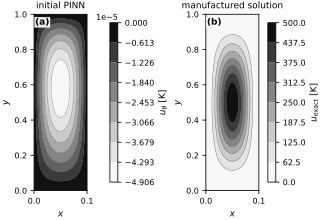

In [6]:
from jax import vmap

v_u_hat = eqx.filter_jit(vmap(u_hat, in_axes=(0, 0, None)))

x = jnp.linspace(0, Lx, 100)
y = jnp.linspace(0, Ly, 100)
X, Y = jnp.meshgrid(x, y)
u_pred = v_u_hat(X.flatten(), Y.flatten(), mlp).reshape(X.shape)

# the true solution for comparison
u_true = u0 * jnp.sin(jnp.pi * X / Lx) ** 2 * jnp.sin(jnp.pi * Y / Ly) ** 2

fig, axes = new_figure("full_landscape", ncols=2)
initial_levels = np.linspace(float(u_pred.min()), float(u_pred.max()), 9)
c = grayscale_contourf(axes[0], X, Y, u_pred, levels=initial_levels)
fig.colorbar(c, ax=axes[0], label=r"$u_{\theta}$ [K]")
axes[0].set(xlabel=r"$x$", ylabel=r"$y$", title="initial PINN")

exact_levels = np.linspace(0.0, float(u0), 9)
c = grayscale_contourf(axes[1], X, Y, u_true, levels=exact_levels)
fig.colorbar(c, ax=axes[1], label=r"$u_{\mathrm{exact}}$ [K]")
axes[1].set(xlabel=r"$x$", ylabel=r"$y$", title="manufactured solution")
label_panels(axes)
finalize_axes(axes, keep_box=True)
plt.show()

## Setting Up the Loss Function

We are going to train this by minimizing the following loss function:

$$
\mathcal{L}(\theta) = \int_{\Omega} \left[ k\Delta u(x, y) + f(x, y) \right]^2 \, dx \, dy.
$$

The first step is to turn the loss function into an expectation.
Construct the random variable $\mathbf{X} = (X,Y)$ uniformly distributed in $\Omega$.
Then, the loss function can be written as:

$$
\mathcal{L}(\theta) = |\Omega|\mathbb{E}\left[ \left[ k\Delta u(\mathbf{X}) + f(\mathbf{X}) \right]^2 \right].
$$

Notice that the volume of $\Omega$, $|\Omega|$, appears as a constant factor.
Where did it come from?
Recall the probability density function of $\mathbf{X}$ is:

$$
p(\mathbf{x}) = \frac{1}{|\Omega|} \quad \text{if} \quad \mathbf{x} \in \Omega, \quad \text{and} \quad 0 \quad \text{otherwise}.
$$

So:

$$
\begin{aligned}
\int_{\Omega} \left[ k\Delta u(\mathbf{x}) + f(\mathbf{x}) \right]^2 \, d\mathbf{x}
&= \int_{\Omega} \left[ k\Delta u(\mathbf{x}) + f(\mathbf{x}) \right]^2 |\Omega|p(\mathbf{x}) \, d\mathbf{x} \\
&= |\Omega|\mathbb{E}\left[ \left[ k\Delta u(\mathbf{X}) + f(\mathbf{X}) \right]^2 \right].
\end{aligned}
$$

We can approximate this expectation by sampling a finite number of points from $\Omega$ and averaging the loss function over these points.
This is what we will be doing in each iteration of the training process.

In [7]:
from jax import grad

# First order derivatives
u_x = grad(u_hat, argnums=0)
u_y = grad(u_hat, argnums=1)

# Second order derivatives
u_xx = grad(u_x, argnums=0)
u_yy = grad(u_y, argnums=1)

# The Laplacian
D2_u = lambda x, y, mlp: u_xx(x, y, mlp) + u_yy(x, y, mlp)

# The source term
source_term = lambda x, y: 2.0 * jnp.pi ** 2 * k * u0 * (
    -Lx ** 2 * jnp.sin(jnp.pi * x / Lx) ** 2 * jnp.cos(2.0 * jnp.pi * y / Ly)
    -Ly ** 2 * jnp.sin(jnp.pi * y / Ly) ** 2 * jnp.cos(2.0 * jnp.pi * x / Lx)
) / (Lx ** 2 * Ly ** 2)

# The PDE residual (vectorize)
pde_residual = vmap(
    lambda x, y, mlp: k * D2_u(x, y, mlp) + source_term(x, y),
    in_axes=(0, 0, None))

# Finally the loss function:
loss = lambda mlp, x, y: Lx * Ly * jnp.mean(jnp.square(pde_residual(x, y, mlp)))

## Training the Model

We use the Adam optimizer with standard parameters. The training algorithm is:

In [8]:
def train(
        loss,
        mlp,
        key,
        optimizer,
        Lx=1.0,
        Ly=1.0,
        num_collocation_residual=512,
        num_iter=10_000,
        freq=1,
    ):

    @eqx.filter_jit
    def step(opt_state, mlp, xs, ys):
        value, grads = eqx.filter_value_and_grad(loss)(mlp, xs, ys)
        updates, opt_state = optimizer.update(grads, opt_state)
        mlp = eqx.apply_updates(mlp, updates)
        return mlp, opt_state, value
    
    opt_state = optimizer.init(eqx.filter(mlp, eqx.is_inexact_array))
    
    losses = []
    for i in range(num_iter):
        key, subkey = jrandom.split(key)
        xb = jrandom.uniform(subkey, (num_collocation_residual,), maxval=Lx)
        key, subkey = jrandom.split(key)
        yb = jrandom.uniform(subkey, (num_collocation_residual,), maxval=Ly)
        mlp, opt_state, value = step(opt_state, mlp, xb, yb)
        if i % freq == 0:
            losses.append(value)
            print(f"Step {i}, residual loss {value:.3e}")
    return mlp, losses

And this is the actual training:

In [9]:
import optax

optimizer = optax.adam(1e-3)
trained_mlp, losses = train(loss, mlp, key, optimizer, num_collocation_residual=256, num_iter=1_000, freq=100, Lx=Lx, Ly=Ly)

Step 0, residual loss 1.756e+16
Step 100, residual loss 1.754e+16


Step 200, residual loss 2.075e+16
Step 300, residual loss 1.794e+16


Step 400, residual loss 1.864e+16
Step 500, residual loss 1.922e+16


Step 600, residual loss 1.915e+16
Step 700, residual loss 2.064e+16


Step 800, residual loss 1.710e+16
Step 900, residual loss 1.886e+16


Let's visualize first the evolution of the loss function:

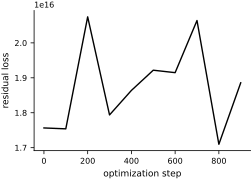

In [10]:
fig, ax = new_figure("half_standard")
steps = 100 * np.arange(len(losses))
ax.plot(steps, losses, color="black", linewidth=1.4)
ax.set(xlabel="optimization step", ylabel="residual loss")
finalize_axes(ax)
plt.show()

The loss does not decrease. The corresponding trained solution is shown below:

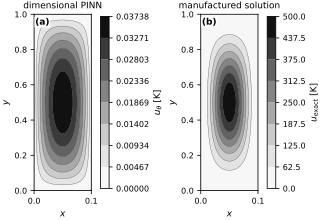

In [11]:
fig, axes = new_figure("full_landscape", ncols=2)
u_pred = v_u_hat(X.flatten(), Y.flatten(), trained_mlp).reshape(X.shape)
prediction_levels = np.linspace(float(u_pred.min()), float(u_pred.max()), 9)
c = grayscale_contourf(axes[0], X, Y, u_pred, levels=prediction_levels)
fig.colorbar(c, ax=axes[0], label=r"$u_{\theta}$ [K]")
axes[0].set(xlabel=r"$x$", ylabel=r"$y$", title="dimensional PINN")

exact_levels = np.linspace(0.0, float(u0), 9)
c = grayscale_contourf(axes[1], X, Y, u_true, levels=exact_levels)
fig.colorbar(c, ax=axes[1], label=r"$u_{\mathrm{exact}}$ [K]")
axes[1].set(xlabel=r"$x$", ylabel=r"$y$", title="manufactured solution")
label_panels(axes)
finalize_axes(axes, keep_box=True)
plt.show()

## Nondimensionalization of Partial Differential Equations

The difficulty is that the dimensional variables and residual terms are on very different scales.
Nondimensionalization brings them to comparable, order-one scales.

We start by picking characteristic lengthscales.
Here, it makes sense to pick $L_x$ and $L_y$ as characteristic lengthscales.
We also need to pick a characteristic value for the temperature, say $u_s$.

$$
\begin{aligned}
    \tilde{x} = \frac{x}{L_x}, \quad \tilde{y} = \frac{y}{L_y}, \quad \tilde{u} = \frac{u}{u_s}.
\end{aligned}
$$

The next step is to find the partial derivatives of $u$ with respect to $x$ and $y$ in terms of the non-dimensional variables:

$$
\frac{\partial u}{\partial x} = \frac{u_s}{L_x}\frac{\partial \tilde{u}}{\partial \tilde{x}}, \quad \frac{\partial u}{\partial y} = \frac{u_s}{L_y}\frac{\partial \tilde{u}}{\partial \tilde{y}}.
$$

Here, we just used the chain rule.

The second derivatives are:

$$
\frac{\partial^2 u}{\partial x^2} = \frac{u_s}{L_x^2}\frac{\partial^2 \tilde{u}}{\partial \tilde{x}^2}, \quad \frac{\partial^2 u}{\partial y^2} = \frac{u_s}{L_y^2}\frac{\partial^2 \tilde{u}}{\partial \tilde{y}^2}.
$$

Plugging these into the original PDE, we get:

$$
-k\left(\frac{u_s}{L_x^2}\frac{\partial^2 \tilde{u}}{\partial \tilde{x}^2} + \frac{u_s}{L_y^2}\frac{\partial^2 \tilde{u}}{\partial \tilde{y}^2}\right) = f.
$$
Define now the non-dimensional source term:

$$
\tilde{f} = \frac{f}{f_s}.
$$

And the non-dimensional thermal conductivity:

$$
\tilde{k}_x = \frac{ku_s}{L_x^2 f_s}, \quad \tilde{k}_y = \frac{ku_s}{L_y^2 f_s}.
$$

The equation becomes:

$$
-\left(\tilde{k}_x\frac{\partial^2 \tilde{u}}{\partial \tilde{x}^2} + \tilde{k}_y\frac{\partial^2 \tilde{u}}{\partial \tilde{y}^2}\right) = \tilde{f},
$$

defined on the non-dimensional domain $\tilde{\Omega} = [0, 1]\times [0, 1]$.

We now choose physical scales rather than estimating them from an untrained network. The manufactured solution has amplitude $u_0$, so we take $u_s=u_0$. For a problem without an exact solution, $u_s$ should come from boundary data, observations, or another characteristic solution scale. We scale the source with

$$
f_s = \|f\|_{\infty} = \max_{(x, y) \in \Omega} |f(x, y)|.
$$

With these choices, the dimensionless solution and source are both of order one. The coefficients $\tilde{k}_x$ and $\tilde{k}_y$ retain the anisotropy created by the two physical length scales. Let's calculate them:

In [12]:
# These functions convert from x to xt and y to yt and vice versa
to_x = lambda xt: xt * Lx
to_y = lambda yt: yt * Ly
to_xt = lambda x: x / Lx
to_yt = lambda y: y / Ly
Xt = to_xt(X)
Yt = to_yt(Y)

fs = jnp.abs(source_term(X.flatten(), Y.flatten())).max()

# Start a random MLP
tmlp = eqx.nn.MLP(2, 1, width_size, depth, jnp.tanh, key=subkey)
tu_hat = lambda tx, ty, tmlp: tx * (1.0 - tx) * ty * (1.0 - ty) * tmlp(jnp.array([tx, ty]))[0]
# Find the required gradients
tu_x = grad(tu_hat, argnums=0)
tu_y = grad(tu_hat, argnums=1)
tu_xx = grad(tu_x, argnums=0)
tu_yy = grad(tu_y, argnums=1)

# Use the known amplitude of the manufactured solution as the solution scale.
us = u0

print(f"Scale factor fs: {fs:.2e}")
print(f"Scale factor us: {us:.2e}")

Scale factor fs: 9.96e+08
Scale factor us: 5.00e+02


Let's check if the left hand side is comparable to the right hand side:

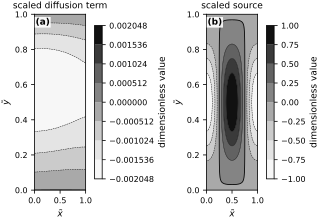

In [13]:
lhs = lambda tx, ty, tmlp: -k * us / fs * (1.0 / Lx ** 2 * tu_xx(tx, ty, tmlp) + 1.0 / Ly ** 2 * tu_yy(tx, ty, tmlp))
v_lhs = eqx.filter_jit(vmap(lhs, in_axes=(0, 0, None)))

fig, axes = new_figure("full_landscape", ncols=2)
tl = v_lhs(Xt.flatten(), Yt.flatten(), tmlp).reshape(X.shape)
lhs_limit = float(jnp.max(jnp.abs(tl)))
lhs_levels = np.linspace(-lhs_limit, lhs_limit, 9)
c = signed_grayscale_contourf(axes[0], Xt, Yt, tl, levels=lhs_levels)
fig.colorbar(c, ax=axes[0], label="dimensionless value")
axes[0].set(
    xlabel=r'$\tilde{x}$',
    ylabel=r'$\tilde{y}$',
    title="scaled diffusion term",
)

tf = source_term(X.flatten(), Y.flatten()).reshape(X.shape) / fs
source_levels = np.linspace(-1.0, 1.0, 9)
c = signed_grayscale_contourf(axes[1], Xt, Yt, tf, levels=source_levels)
fig.colorbar(c, ax=axes[1], label="dimensionless value")
axes[1].set(
    xlabel=r'$\tilde{x}$',
    ylabel=r'$\tilde{y}$',
    title="scaled source",
)

label_panels(axes)
finalize_axes(axes, keep_box=True)
plt.show()

The two sides are now expressed on dimensionless scales. They are not expected to match before training; the point of this check is to rule out a many-orders-of-magnitude mismatch at initialization.

Here is what the scaled conductivity looks like:

In [14]:
tkx = (k * us) / (Lx ** 2 * fs)
tky = (k * us) / (Ly ** 2 * fs)
print(f"tkx = {tkx:.3e}, tky = {tky:.3e}") 

tkx = 5.020e-02, tky = 5.020e-04


Let's now try training the scaled version of the problem:

In [15]:
tmlp = eqx.nn.MLP(2, 1, width_size, depth, jnp.tanh, key=subkey)
tu_hat = lambda tx, ty, tmlp: tx * (1.0 - tx) * ty * (1.0 - ty) * tmlp(jnp.array([tx, ty]))[0]
tu_x = grad(tu_hat, argnums=0)
tu_y = grad(tu_hat, argnums=1)
tu_xx = grad(tu_x, argnums=0)
tu_yy = grad(tu_y, argnums=1)
tilde_source_term = lambda tx, ty: source_term(to_x(tx), to_y(ty)) / fs
tpde_residual = vmap(
    lambda tx, ty, tmlp: tkx * tu_xx(tx, ty, tmlp) + tky * tu_yy(tx, ty, tmlp) + tilde_source_term(tx, ty),
    in_axes=(0, 0, None))
tloss = lambda tmlp, tx, ty: jnp.mean(jnp.square(tpde_residual(tx, ty, tmlp)))

In [16]:
optimizer = optax.adam(1e-3)
trained_tmlp, losses = train(tloss, tmlp, key, optimizer, num_collocation_residual=256, num_iter=2_000, freq=100, Lx=1.0, Ly=1.0)

Step 0, residual loss 1.772e-01
Step 100, residual loss 6.593e-02


Step 200, residual loss 1.982e-02
Step 300, residual loss 1.157e-02


Step 400, residual loss 1.060e-02
Step 500, residual loss 1.115e-02


Step 600, residual loss 8.039e-03
Step 700, residual loss 6.738e-03


Step 800, residual loss 5.067e-03
Step 900, residual loss 3.802e-03


...

Step 1200, residual loss 7.406e-04
Step 1300, residual loss 4.616e-04


Step 1400, residual loss 2.862e-04
Step 1500, residual loss 2.180e-04


Step 1600, residual loss 1.337e-04


Step 1700, residual loss 9.229e-05
Step 1800, residual loss 7.829e-05


Step 1900, residual loss 4.149e-05


```{note}
Training time depends on the available hardware and includes the initial JAX compilation.
```

We save this loss for the next section.

In [17]:
import numpy as np
np.savez("mlp_losses.npz", losses=losses)

Here is the loss function:

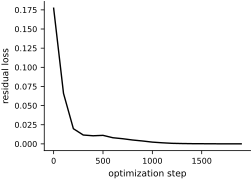

In [18]:
fig, ax = new_figure("half_standard")
steps = 100 * np.arange(len(losses))
ax.plot(steps, losses, color="black", linewidth=1.4)
ax.set(xlabel="optimization step", ylabel="residual loss")
finalize_axes(ax)
plt.show()

And here is the solution scaled back to the original domain:

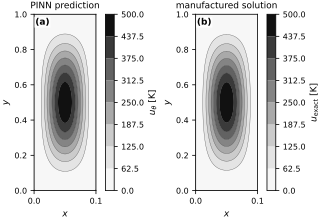

In [19]:
v_tu_hat = vmap(tu_hat, in_axes=(0, 0, None))
fig, axes = new_figure("full_landscape", ncols=2)
u_pred = v_tu_hat(to_xt(X.flatten()), to_yt(Y.flatten()), trained_tmlp).reshape(X.shape)
temperature_levels = np.linspace(0.0, float(u0), 9)
c = grayscale_contourf(axes[0], X, Y, u_pred * us, levels=temperature_levels)
fig.colorbar(c, ax=axes[0], label=r'$u_{\theta}$ [K]')
axes[0].set(xlabel=r'$x$', ylabel=r'$y$', title="PINN prediction")
c = grayscale_contourf(axes[1], X, Y, u_true, levels=temperature_levels)
fig.colorbar(c, ax=axes[1], label=r'$u_{\mathrm{exact}}$ [K]')
axes[1].set(xlabel=r'$x$', ylabel=r'$y$', title="manufactured solution")
label_panels(axes)
finalize_axes(axes, keep_box=True)
plt.show()

The point wise error is here:

Relative L2 error: 1.452e-02


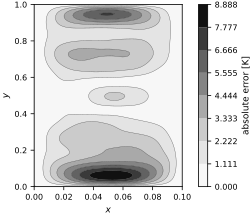

In [20]:
fig, ax = new_figure("half_tall")
pointwise_error = jnp.abs(u_pred * us - u_true)
relative_l2_error = jnp.linalg.norm(u_pred * us - u_true) / jnp.linalg.norm(u_true)
print(f"Relative L2 error: {relative_l2_error:.3e}")
error_levels = np.linspace(0.0, float(pointwise_error.max()), 9)
c = grayscale_contourf(ax, X, Y, pointwise_error, levels=error_levels)
fig.colorbar(c, ax=ax, label="absolute error [K]")
ax.set(xlabel=r'$x$', ylabel=r'$y$')
finalize_axes(ax, keep_box=True)
plt.show()

It is very hard to achieve better error with plain MLPs.